# UM4MA266, Numerical optimization and Data science
## STEREO Project

Student : SIDATE Mathieu<br>
Sorbonne Université, 2025-2026

## Research phase

### 1. Implementation de la méthode de block matching 

#### 1.1. Calcul du SSD (Sum of Squared differences)

On a que,
$$
C(x,y,d) = \displaystyle\sum_{(i,j)\in\cal{W}} |{I}_{L}(x+i, y+j) - {I}_{R}(x+i-d(x, y), y+j)|^2, \tag{1}
$$
avec $\cal{W}$ notre window (ou bloc) de pixels,<br><br> 
${I}_{L}$ et ${I}_{R}$ nos images gauche droite qui renvoient ici une valeur spécifique à un pixel (généralement la luminosité sur une image mis en niveau de gris).

ps: faire une section approfondissement sur la fonction de perte SSD/SAD qui ne sont pas forcément les meilleures

In [66]:
import numpy as np
import cv2
import os

In [67]:
print(os.getcwd())

/Users/mathieu/academic/cs/py_stuff/opti_tp/project


Pour avoir le bon format d'image pour le computer vision, on prend deux images en PNG ou JPEG (normalement les deux marchent) et on les met en grayscale cv2.imread(img, cv2.IMREAD_GRAYSCALE)

<span style="color:green"> <u>Thoughts:</u> 
- Comment on gère la window; centrée en un point, commence au coin supérieur gauche ?<br>
- Doit-on, pour chaque pixel dans une fenêtre, calculer le SSD local ou, pour chaque pixel, créer une fenêtre de taille window et calculer le SSD ? 
</span>

On essaie avec centré en un point et pour chaque pixel, window ssd. (ça à l'air d'être comme ça avec OpenCV)

<span style="color:green"> <u>2nd Thought:</u>
Dans la question 1, de ce que j'ai compris, on regarde TOUS les pixels de l'image et créer une fenêtre à chaque fois
</span>

In [68]:
# Méthode de SSD local avec fenêtre en brutforce

def ssd(l_img, r_img, D_max, window):
    """
    Args :
        [l_img] array de pixels (dim = résolution image) de l'image gauche ayant pour valeur la luminosité
        [r_img] // pour l'image droite
        [d] disparité (ie. écart horizontal entre 2 pixels)
        [window] taille de notre fenêtre carrée de pixel

    Outputs :
        [disp_map] carte de disparité (dim(img)) qui minimise le coût de correspondance total (+ il est faible + les images à translation d près sont similaires)
                   avec d_ij dans disp_map à valeurs dans [0,D_max]
    Assumptions :
        - dim(l_img) = dim(r_img)
        - taille de window < taille d'image
        - disparité D_max < largeur image
    """

    h, w = l_img.shape  # hauteur (height) , largeur (width) des images
    half_win = window // 2
    disp_map = np.zeros([h, w])    
    
    # création du padding
    padded_l_img = cv2.copyMakeBorder(l_img, top=half_win, bottom=half_win, left=half_win, right=half_win, borderType=cv2.BORDER_REFLECT)
    padded_r_img = cv2.copyMakeBorder(r_img, top=half_win, bottom=half_win, left=half_win, right=half_win, borderType=cv2.BORDER_REFLECT)
    
    # On parcourt tous les pixels de l'image (grâce au padding)
    for y in range(h):
        for x in range(w):
            
            best_cost = float('inf') # valeur élevée pour que tous les autres coup soient inférieurs
            
            for d in range(D_max):
                
                I_ls = padded_l_img[y:y+window, x:x+window]             # fenêtre centrée en (x,y)   
                
                if x-d >= 0 and x-d <= w: # même si le 2ème point est évident 
                    I_rs = padded_r_img[y:y+window, x-d:x-d+window]       # fenêtre centrée en (x-d, y)
                else:
                    continue
                    
                cost = np.sum((I_ls - I_rs)**2)

                if cost < best_cost:
                    disp_map[y, x] = d
                    best_cost = cost
                    
    
    return disp_map 

### Problems encountered:

- On va changer cette fonction prcq c'est pas vraiment ça qu'on veut. Ce qu'on veut c'est une fonction qui pour un pixel donné va créer une window autour et calculer le ssd window pour trouver le disp_opt de ce pixel.
- J'ai un problème avec ma disp_map car elle sera, en l'état actuel, de dimension < à dim(img), car on ne prend en compte que les pixels pouvant être au centre d'une window de taille w. Une solution pour régler ça est de faire du padding c'est à dire rajouter artifiellement des pixels autour de l'image pour que tous les pixels de l'image initiale soient pris en compte.

nb : faire un petit schéma pour expliquer choix de fenêtre et système de padding

In [69]:
A = np.random.rand(30, 30)
B = np.random.rand(30, 30)
print(ssd(A, B, 10, 3))
ssd(A, A, 10, 3) # le coût est bien nul comme les images sont les mêmes => disparité optimale = 0

[[0. 0. 0. 3. 3. 4. 4. 0. 2. 0. 9. 9. 5. 1. 7. 0. 9. 1. 1. 4. 7. 8. 8. 5.
  5. 5. 4. 1. 1. 1.]
 [0. 0. 2. 3. 3. 4. 0. 0. 2. 0. 9. 5. 5. 1. 0. 0. 9. 4. 4. 4. 7. 8. 8. 1.
  2. 5. 4. 1. 6. 1.]
 [0. 0. 0. 0. 3. 0. 0. 0. 0. 0. 0. 0. 6. 6. 6. 4. 4. 4. 4. 4. 8. 9. 9. 9.
  9. 5. 7. 6. 6. 9.]
 [0. 0. 2. 2. 2. 0. 6. 0. 2. 9. 1. 1. 0. 3. 2. 5. 1. 4. 9. 5. 9. 9. 1. 9.
  9. 3. 6. 6. 6. 8.]
 [0. 0. 0. 0. 2. 0. 2. 2. 2. 2. 2. 5. 3. 3. 2. 7. 7. 4. 5. 5. 8. 8. 9. 9.
  9. 6. 6. 6. 0. 6.]
 [0. 1. 2. 3. 0. 2. 2. 3. 2. 5. 5. 5. 3. 7. 7. 7. 7. 4. 5. 5. 0. 8. 2. 3.
  3. 3. 2. 5. 5. 0.]
 [0. 1. 1. 1. 0. 1. 2. 4. 5. 5. 5. 5. 3. 9. 7. 7. 7. 7. 7. 5. 5. 0. 2. 3.
  2. 6. 4. 4. 0. 0.]
 [0. 1. 2. 2. 1. 1. 2. 3. 3. 5. 5. 5. 3. 9. 7. 1. 6. 8. 0. 0. 0. 5. 6. 6.
  3. 9. 8. 3. 6. 6.]
 [0. 1. 0. 1. 0. 1. 4. 6. 3. 3. 4. 4. 9. 9. 6. 1. 6. 0. 0. 0. 6. 4. 6. 4.
  7. 9. 8. 0. 6. 3.]
 [0. 1. 1. 1. 4. 5. 5. 5. 3. 3. 4. 8. 9. 3. 3. 3. 6. 4. 5. 5. 6. 6. 5. 5.
  3. 0. 0. 0. 3. 3.]
 [0. 1. 1. 1. 4. 4. 4. 5. 7. 3. 8. 8. 2. 2. 2. 1. 

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0

Ca a l'air de marcher en ayant pris l'exemple d'images aléatoire. Avec cette méthode, on va juste faire du brutforce.

### 2. Régularisation du problème

Notre but est de trouver $d^* \in \mathbb{N}^{h * w}$ tel que $d^* = \displaystyle \arg\min_{d \in \mathbb{N}^{h * w}} C_{tot}(d)$

<span style="margin-left:2em;"> où, $C_{tot}(d) = \displaystyle \sum_{(x,y) \in I} C(x,y,d(x, y))$</span>
<span style="margin-left:2em;"> avec $I$ la dimension de la matrice de pixels. </span>

On aimerait utiliser les techniques d'optimisation usuelles sur $C_{tot}$ pour trouver un minimiseur mais un problème premier étant que la fonction n'est pas régulière.

En effet, d(x, y) est à valeur dans $\mathbb{N}$ et on ne sait rien de la différentiabilité de la fonction $I_{R}$ qui est cruciale dans le calcul de différentielle de $(1)$.

Prenons le cas simple du SSD local sans fenêtre :
$$
C(x,y,d) = |I_{L}(x,y) - I_{R}(x-d(x,y),y)|^2
$$

#### 2.1. Prolongement continue de C

On construit $\bar{C}$ tel que $\forall d \in \mathbb{R_{+}}, \bar{C}(x,y,d)$ différentiable et $\bar{C}(x,y,d) = C(x,y,d), \forall d \in \mathbb{N} $

On va utiliser la technique d'interpolation linéaire pour se retrouver avec une fonction qui est C1 par morceaux (les points compliqués étant les points entiers qui sont les démarcations de notre maillage) mais ce n'est pas un problème (? à confirmer) car les techniques d'optimisations ne tomberont presque sûrement pas en ces points.

#### Interpolation linéaire

$\large \bar{f}(x) = \frac{x_{b} - x}{x_{b} - x_{a}}y_{a} + \frac{x - x_{a}}{x_{b} - x_{a}}y_{b},  \forall x \in [x_{a},x_{b}]$</br></br>
tel que $f(x_a)=y_a$ et $f(x_b)=y_b$

Ce qui pose problème c'est quand $u = (x-d) \in \mathbb{R}_{+}$ </br>
donc on pose $\forall u \in \mathbb{R_{+}}, \bar{I}(u,y) = (\lceil u \rceil - u)I(\lfloor u \rfloor,y) + (u - \lfloor u \rfloor)I(\lceil u \rceil,y)$

On a donc, 
$$
\bar{C}(x,y,d) = |I_{L}(x,y) - \bar{I}_{R}(x-d,y)|^2
$$
et,
$$
\bar{C}_{tot}(d) = \displaystyle \sum_{(x,y)} |I_{L}(x,y) - \bar{I}_{R}(x-d,y)|^2
$$
$$
\frac{\partial{\bar{C}_{tot}}}{\partial{d}} = 2 \displaystyle \sum_{(x,y)} (I_R(i+1,y) - I_R(i,y))(I_L(x,y) - \bar{I}_R(x-d,y))
$$
<span style="margin-left:2em;">où, $i = \lfloor u \rfloor$ </span>

In [70]:
def interpol_IR(IR, x, y, d):
    return (np.floor(x-d) + 1 - (x-d)) * IR(np.floor(x-d), y) + (x-d - np.floor(x-d)) * IR(np.floor(x-d) + 1, y)

In [71]:
def grad_d(interpol, IR, IL, x, y, d):
    i = np.floor(x-d)
    return 2 * (IR(i+1, y) - IR(i, y)) * (IL(x,y) - interpol(IR, x, y, d))

### 3. Optimisation du problème

Je choisis une méthode simple (pour l'instant, à voir si il y a mieux) de descente de gradient à pas fixe.

$$
d^{(k+1)} = d^{(k)} - \rho \nabla \bar{C}_{tot}(d^{(k)})
$$

### 4. Implémentation de la méthode semi-globale (SGM) 

#### 4.1. Calcul de l'énergie globale

In [122]:
def compute_cost_volume(l_img, r_img, D_max, window):
    
    h, w = l_img.shape
    cost = np.zeros((h, w, D_max), dtype=np.float32)
    half_win = window // 2
    padded_l_img = cv2.copyMakeBorder(l_img, top=half_win, bottom=half_win, left=half_win, right=half_win, borderType=cv2.BORDER_REFLECT)
    padded_r_img = cv2.copyMakeBorder(r_img, top=half_win, bottom=half_win, left=half_win, right=half_win, borderType=cv2.BORDER_REFLECT)

    # On parcourt tous les pixels de l'image (grâce au padding)
    for y in range(h):
        for x in range(w):
            
            for d in range(D_max):
                
                I_ls = padded_l_img[y:y+window, x:x+window]             # fenêtre centrée en (x,y)   
                
                if x-d >= 0 and x-d <= w: # même si le 2ème point est évident 
                    I_rs = padded_r_img[y:y+window, x-d:x-d+window]       # fenêtre centrée en (x-d, y)
                else:
                    continue
                    
                cost[:, :, d] = np.sum((I_ls - I_rs)**2)
                
    return cost

In [134]:
def sgm_aggregate(cost, P1=5, P2=100, lambd=1):
    H, W, D = cost.shape
    directions = [
        (0, 1),   # east
        (0, -1),  # west
        (1, 0),   # south
        (-1, 0),  # north
        (1, 1),   # south east
        (-1, -1), # north west
        (1, -1),  # south west
        (-1, 1),  # north east
    ]

    S = np.zeros_like(cost)

    for dy, dx in directions:
        L = np.zeros_like(cost)

        y_range = range(H) if dy >= 0 else range(H-1, -1, -1)
        x_range = range(W) if dx >= 0 else range(W-1, -1, -1)

        for y in y_range:
            for x in x_range:
                y_prev = y - dy
                x_prev = x - dx

                if 0 <= y_prev < H and 0 <= x_prev < W:
                    prev = L[y_prev, x_prev]

                    prev_min = prev.min()

                    l1 = prev
                    l2 = np.roll(prev, 1) + lambd * P1
                    l3 = np.roll(prev, -1) + lambd * P1
                    l4 = np.full(D, prev_min + lambd * P2, dtype=np.float32)

                    l2[0] = 1e9
                    l3[-1] = 1e9

                    L[y, x] = cost[y, x] + np.minimum.reduce([l1, l2, l3, l4]) - prev_min
                else:
                    L[y, x] = cost[y, x]

        S += L

    return S

In [135]:
def sgm_disparity_optimized(imgL, imgR, D_max=64, window=15, P1=10, P2=100, lambd=1):
    imgL = imgL.astype(np.float32)
    imgR = imgR.astype(np.float32)
    
    cost = compute_cost_volume(imgL, imgR, D_max, window)
    S = sgm_aggregate(cost, P1, P2, lambd)
    disp = np.argmin(S, axis=2)

    return disp.astype(np.float32)

In [131]:
A = np.random.rand(70, 70)
B = np.random.rand(70, 70)
sgm_disparity_optimized(A, B)

array([[3., 3., 3., ..., 3., 3., 3.],
       [3., 3., 3., ..., 3., 3., 3.],
       [3., 3., 3., ..., 3., 3., 3.],
       ...,
       [3., 3., 3., ..., 3., 3., 3.],
       [3., 3., 3., ..., 3., 3., 3.],
       [3., 3., 3., ..., 3., 3., 3.]], shape=(70, 70), dtype=float32)

normal car bruit gaussien donc ça sort une constante de disp pour tous les pixels

In [133]:
sgm_disparity_optimized(A, A)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(70, 70), dtype=float32)

### 5. Pyramide multi-échelle

## Strategy:

- downscale de 2^K les images (check)
- brutforce disparity d_prov (check /pour BM)
- upscale x2 et faire descente de gradient sur un intervalle [d_prov +- delta] avec delta de l'ordre de (2-4 px)
- boucle où on refait la même chose ie. upscale et descente de gradient avec un intervalle centré en le nv d_prov obtenu avant (tjrs delta = 2-4px)
- quand on la fait jusqu'à la Kème fois, ie. pleine résolution, on retourne la disparité

In [73]:
def resize_img(img, scale):
    """
    Args:
        [img] image de base cv2 convert en greyscale matrix
        [scale] facteur de downscaling (ex: scale=1/2 (2) pour downscale (upscale) d'un facteur 2)

    Outputs:
        - image downscale (upscale) d'un facteur 1/scale (scale)
    """
    h, w = img.shape
    h_new, w_new = int(scale * h), int(scale * w)

    return cv2.resize(img, (w_new, h_new), interpolation=cv2.INTER_AREA) # better interpolation when it comes to downscaling

In [97]:
def upscaling_disp(disp, scale, new_dim):
    """
    Args:
        [disp] carte de disparité (dim(downscale_img)), qui en pratique, est celle issue de l'image downscale 
        [scale] facteur d'upscale
        [new_dim] dimension de l'image upscale (h, w)

    Outputs:
        [up_disp] carte de disparité upscale

    Assumptions:
        - new_dim et scale sont liés: dim(disp) * scale = new_dim
    """
    h, w = new_dim
    up_disp = cv2.resize(disp.astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR) # on utilise cette interpolation car plus stable pour des valeurs physiques

    return up_disp * scale # on avait la bonne dim de disp_map mais pas à la bonne échelle
    

In [106]:
def build_pyramid(img, lvls):
    """
    """
    pyramid = [img]
    
    for i in range(lvls - 1):
        pyramid.append(cv2.pyrDown(pyramid[-1]))
    
    return pyramid

In [107]:
#fonction finale qu'on utilisera mais d'abord on a besoin des fonctions ci-dessus

def multiscale_pyramid_method1(l_img, r_img, K, D_max, window):
    """
    Args:
        []
    """
    pyr_l = build_pyramid(l_img, K)
    pyr_r = build_pyramid(r_img, K)
    disp = None
    
    for lvl in range(K-1, -1, -1):
        imgL_k = pyr_l[lvl]    
        imgR_k = pyr_r[lvl]
        h, w = imgL_k.shape

        D_max_k = max(16, D_max // (2**lvl) // 16 * 16)

        if disp is None:
            disp = ssd(imgL_k, imgR_k, D_max_k, window)
        else:
            disp = upscaling_disp(disp, 2, (h, w))
            refine_range = max(16, D_max // (4 * 2**lvl) // 16 * 16)
            disp_corr = ssd(imgL_k, imgR_k, refine_range, window).astype(np.float32) / 16.0
            disp += disp_corr
    return disp

In [ ]:
imgL = cv2.imread("img_files/couch/im0.png", cv2.IMREAD_GRAYSCALE)
imgR = cv2.imread("img_files/couch/im1.png", cv2.IMREAD_GRAYSCALE)
multiscale_pyramid_method1(imgL, imgR, K=3, D_max=64, window=15)

result in 332sec...

In [ ]:
def compute_gradient_step(imgL, imgR, disp, alpha=0.5):
    """
    1 step de descente de gradient sur la disparité
    """

    H, W = imgL.shape
    grad = np.zeros_like(disp)

    # interpolation subpixel (important 🔥)
    x_coords = np.arange(W)[None, :]
    x_shifted = x_coords - disp

    # clamp
    x0 = np.floor(x_shifted).astype(int)
    x1 = x0 + 1

    x0 = np.clip(x0, 0, W-1)
    x1 = np.clip(x1, 0, W-1)

    w = x_shifted - x0

    IR_interp = (1 - w) * imgR[:, x0] + w * imgR[:, x1]

    # gradient du coût (L2 approx)
    diff = imgL - IR_interp

    # approx dérivée par rapport à d
    grad = -diff

    # régularisation (laplacien simple)
    lap = (
        -4 * disp +
        np.roll(disp, 1, axis=0) +
        np.roll(disp, -1, axis=0) +
        np.roll(disp, 1, axis=1) +
        np.roll(disp, -1, axis=1)
    )

    return grad + alpha * lap

In [136]:
def refine_disparity(imgL, imgR, disp_init,
                     n_iter=10, step=0.1, alpha=0.5):

    disp = disp_init.copy()

    for _ in range(n_iter):
        grad = compute_gradient_step(imgL, imgR, disp, alpha)
        disp = disp - step * grad

    return disp

In [137]:
def multiscale_sgm_with_refinement(imgL, imgR, levels=3, D=64, P1=10, P2=120, refine_iter=5):

    pyrL = build_pyramid(imgL, levels)
    pyrR = build_pyramid(imgR, levels)

    disp = None

    for level in range(levels - 1, -1, -1):
        IL = pyrL[level]
        IR = pyrR[level]

        h, w = IL.shape

        if disp is None:
            # niveau grossier
            disp = sgm_disparity_optimized(IL, IR, D, P1, P2)

        else:
            # upscale
            disp = cv2.resize(disp, (w, h),
                              interpolation=cv2.INTER_LINEAR) * 2.0

            disp = refine_disparity(IL, IR, disp, n_iter=refine_iter, step=0.1, alpha=0.3)

    return disp

In [138]:
multiscale_sgm_with_refinement(imgL, imgR)

KeyboardInterrupt: 

In [141]:
def multiscale_disparity(img_left, img_right, num_levels=3, num_disp=64, block=15):
    pyr_L = build_pyramid(img_left, num_levels)
    pyr_R = build_pyramid(img_right, num_levels)
    disp = None # pas encore d’estimation
    for level in range(num_levels - 1, -1, -1): 
        IL_k = pyr_L[level]
        IR_k = pyr_R[level]
        H_k, W_k = IL_k.shape
        # Plage de disparites adaptee au niveau
        num_disp_k = max(16, num_disp // (2**level) // 16 * 16)
        if disp is None:
            # Niveau le plus grossier : initialisation standard
            stereo = cv2.StereoBM_create(numDisparities=num_disp_k, blockSize=block)
            disp = stereo.compute(IL_k, IR_k).astype(np.float32) / 16.0
        else:
            # Agrandissement et rescaling (x2 en resolution -> x2 en disparite)
            disp = cv2.resize(disp, (W_k, H_k),
            interpolation=cv2.INTER_LINEAR) * 2.0
            # Raffinement : fenetre de recherche etroite autour de disp
            refine_range = max(16, num_disp // (4 * 2**level) // 16 * 16)
            stereo = cv2.StereoBM_create(numDisparities=refine_range,
            blockSize=block)
            correction = stereo.compute(IL_k, IR_k).astype(np.float32) / 16.0
            disp = disp + correction # correction additive autour de l’estimation
    return disp

In [144]:
multiscale_disparity(imgL, imgR)

array([[-7., -7., -7., ..., -7., -7., -7.],
       [-7., -7., -7., ..., -7., -7., -7.],
       [-7., -7., -7., ..., -7., -7., -7.],
       ...,
       [-7., -7., -7., ..., -7., -7., -7.],
       [-7., -7., -7., ..., -7., -7., -7.],
       [-7., -7., -7., ..., -7., -7., -7.]],
      shape=(1992, 2300), dtype=float32)

## Ce qu'il reste à faire:

- cas avec contraintes (SGM) maths/code
- voir en pratique la performance des différents outils algorithmiques
- influence des param ss contrainte
- prendre des photos qui vérifient des caractéristiques différentes (bcp de détails par ex)

Notes: 

- Il faut utiliser la méthode brut force, càd qu'on va downgrade l'image (disons de x10 les pixels de l'image) et dessus on va tester tous les d jusqu'à un $d_{max}$ pour avoir un minima local sur une petite fenêtre. Ensuite, on re upgrade l'image (on a plusieurs minima locaux) et on passe au cas continu

nb: faire le lien avec les ressources Pytorch du pdf qui mettent en lumière le fait que les méthodes qu'on utilise là sont rudimentaires et que l'on pourrait faire mieux avec des méthodes de Deep Learning.

## Goal:

- on a la distance focale f et la Baseline B, on veut trouver la disparité, qui est une FONCTION d(x,y), propre à chacun des pixels; plus un objet est proche des caméras plus il sera sujet à une grande disparité.
- L'optimisation nous permet de retrouver la CARTE de disparité
- Avec ça on peut retrouver la profondeur z d'un pixel dans l'image avec la formule $d = \frac{f \cdot B}{z}$
- On a alors une carte de profondeur et on peut représenter l'image en depthscale (cf. Middleburry depthscale image stereovision)

## Functions to know:

In [ ]:
cv2.imread?

In [ ]:
cv2.IMREAD_GRAYSCALE?

In [ ]:
cv2.resize?

In [ ]:
cv2.copyMakeBorder?

In [ ]:
cv2.pyrDown?

In [146]:
import cv2
import numpy as np


def build_pyramid(img, levels):
    """
    Pyramide gaussienne du plus fin au plus grossier.
    """
    pyr = [img]
    for _ in range(levels - 1):
        pyr.append(cv2.pyrDown(pyr[-1]))
    return pyr


def shift_image_right(img, disp):
    """
    Warp horizontal de l'image droite selon une carte de disparité disp.
    img  : image float32, shape (H, W)
    disp : float32, shape (H, W), déplacement horizontal vers la gauche
    """
    h, w = img.shape
    x, y = np.meshgrid(np.arange(w, dtype=np.float32),
                       np.arange(h, dtype=np.float32))
    map_x = x - disp.astype(np.float32)
    map_y = y
    return cv2.remap(
        img, map_x, map_y,
        interpolation=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )


def local_ssd_correction(left, right_warped, max_delta=2, block_size=7):
    """
    Calcule une correction locale de disparité autour d'une image droite déjà warpée.
    On ne cherche que delta dans [-max_delta, ..., +max_delta].
    Utilise SSD fenêtré avec boxFilter, beaucoup plus rapide qu'une double boucle Python.
    """
    assert block_size % 2 == 1, "block_size doit être impair"

    left = left.astype(np.float32)
    right_warped = right_warped.astype(np.float32)

    h, w = left.shape
    deltas = np.arange(-max_delta, max_delta + 1, dtype=np.int32)

    costs = []
    for d in deltas:
        if d < 0:
            # on décale l'image droite warpée vers la gauche
            shifted = np.zeros_like(right_warped)
            shifted[:, :w + d] = right_warped[:, -d:]
        elif d > 0:
            shifted = np.zeros_like(right_warped)
            shifted[:, d:] = right_warped[:, :w - d]
        else:
            shifted = right_warped

        diff2 = (left - shifted) ** 2
        ssd = cv2.boxFilter(
            diff2, ddepth=-1,
            ksize=(block_size, block_size),
            normalize=False,
            borderType=cv2.BORDER_REFLECT
        )
        costs.append(ssd)

    cost_volume = np.stack(costs, axis=0)  # (D, H, W)
    best_idx = np.argmin(cost_volume, axis=0)
    correction = deltas[best_idx].astype(np.float32)

    # Raffinement subpixel simple par interpolation quadratique
    valid = (best_idx > 0) & (best_idx < len(deltas) - 1)
    yv, xv = np.where(valid)
    i = best_idx[yv, xv]

    c1 = cost_volume[i - 1, yv, xv]
    c2 = cost_volume[i,     yv, xv]
    c3 = cost_volume[i + 1, yv, xv]

    denom = 2.0 * (c1 - 2.0 * c2 + c3)
    good = np.abs(denom) > 1e-6
    sub = np.zeros_like(c2, dtype=np.float32)
    sub[good] = (c1[good] - c3[good]) / denom[good]

    correction[yv[good], xv[good]] += sub[good]
    return correction


def left_right_consistency_filter(disp_left, disp_right, thresh=1.5):
    """
    Filtre de cohérence gauche-droite pour enlever les faux appariements.
    """
    h, w = disp_left.shape
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    xr = np.round(x - disp_left).astype(np.int32)

    valid = (xr >= 0) & (xr < w)
    dr = np.zeros_like(disp_left, dtype=np.float32)
    dr[valid] = disp_right[y[valid], xr[valid]]

    ok = valid & (np.abs(disp_left - dr) <= thresh)
    out = disp_left.copy()
    out[~ok] = 0.0
    return out, ok


def fill_invalid_horizontal(disp, valid_mask):
    """
    Remplit les trous grossièrement par propagation horizontale.
    """
    out = disp.copy()
    h, w = out.shape

    for y in range(h):
        # gauche -> droite
        last = 0.0
        for x in range(w):
            if valid_mask[y, x]:
                last = out[y, x]
            else:
                out[y, x] = last

        # droite -> gauche pour les zones encore nulles
        last = 0.0
        for x in range(w - 1, -1, -1):
            if valid_mask[y, x]:
                last = out[y, x]
            elif out[y, x] == 0.0:
                out[y, x] = last

    return out


def multiscale_stereo_refined(
    img_left,
    img_right,
    levels=4,
    max_disp=192,
    block_size_coarse=9,
    block_size_fine=7,
    refine_delta=2,
    median_ksize=5
):
    """
    Carte de disparité coarse-to-fine avec raffinement local SSD.

    Paramètres conseillés pour ~2000x2300 :
    - levels=4
    - max_disp=160 à 256
    - refine_delta=2 ou 3

    Retour :
    - disp_left  : disparité finale gauche -> droite
    - disp_right : disparité finale droite -> gauche
    """

    # Passage en niveaux de gris si besoin
    if img_left.ndim == 3:
        img_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
    if img_right.ndim == 3:
        img_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

    # Légère normalisation / contraste
    img_left = cv2.equalizeHist(img_left)
    img_right = cv2.equalizeHist(img_right)

    pyrL = build_pyramid(img_left, levels)
    pyrR = build_pyramid(img_right, levels)

    disp_left = None
    disp_right = None

    for level in range(levels - 1, -1, -1):
        L = pyrL[level].astype(np.float32)
        R = pyrR[level].astype(np.float32)
        h, w = L.shape

        if disp_left is None:
            # Niveau le plus grossier :
            # initialisation rapide avec StereoBM
            num_disp = max(16, ((max_disp // (2 ** level)) // 16) * 16)
            if num_disp < 16:
                num_disp = 16

            bm = cv2.StereoBM_create(
                numDisparities=num_disp,
                blockSize=block_size_coarse
            )

            dL = bm.compute(L.astype(np.uint8), R.astype(np.uint8)).astype(np.float32) / 16.0
            dR = bm.compute(R.astype(np.uint8), L.astype(np.uint8)).astype(np.float32) / 16.0

            dL[dL < 0] = 0
            dR[dR < 0] = 0

            disp_left = dL
            disp_right = dR

        else:
            # Upsampling de l'estimation précédente
            disp_left = cv2.resize(disp_left, (w, h), interpolation=cv2.INTER_LINEAR) * 2.0
            disp_right = cv2.resize(disp_right, (w, h), interpolation=cv2.INTER_LINEAR) * 2.0

            # Raffinement gauche -> droite
            Rw = shift_image_right(R, disp_left)
            corrL = local_ssd_correction(
                L, Rw,
                max_delta=refine_delta,
                block_size=block_size_fine
            )
            disp_left = disp_left + corrL
            disp_left[disp_left < 0] = 0

            # Raffinement droite -> gauche
            Lw = shift_image_right(L, disp_right)
            corrR = local_ssd_correction(
                R, Lw,
                max_delta=refine_delta,
                block_size=block_size_fine
            )
            disp_right = disp_right + corrR
            disp_right[disp_right < 0] = 0

        # Petit post-traitement à chaque niveau
        disp_left = cv2.medianBlur(disp_left.astype(np.float32), 5)
        disp_right = cv2.medianBlur(disp_right.astype(np.float32), 5)

    # Cohérence gauche-droite
    disp_left, valid = left_right_consistency_filter(disp_left, disp_right, thresh=1.5)

    # Remplissage des trous
    disp_left = fill_invalid_horizontal(disp_left, valid)

    # Lissage final conservant mieux les contours
    disp_left = cv2.bilateralFilter(disp_left.astype(np.float32), d=7, sigmaColor=8, sigmaSpace=8)

    return disp_left, disp_right


def disparity_to_uint8(disp):
    """
    Pour affichage uniquement.
    """
    disp_vis = disp.copy()
    disp_vis[disp_vis < 0] = 0
    disp_vis = cv2.normalize(disp_vis, None, 0, 255, cv2.NORM_MINMAX)
    return disp_vis.astype(np.uint8)

In [148]:
disp, _ = multiscale_stereo_refined(
    imgL,
    imgR,
    levels=4,
    max_disp=192,
    block_size_coarse=11,
    block_size_fine=7,
    refine_delta=2
)

disp_vis = disparity_to_uint8(disp)
cv2.imwrite("disparity.png", disp_vis)
disp

array([[0.        , 0.01681899, 0.1028446 , ..., 2.4205444 , 2.4205444 ,
        2.4205444 ],
       [0.        , 0.01681899, 0.10280822, ..., 2.249829  , 2.249829  ,
        2.249829  ],
       [0.        , 0.01676644, 0.10263306, ..., 3.011213  , 3.011213  ,
        3.011213  ],
       ...,
       [0.        , 0.        , 0.        , ..., 2.3064694 , 2.3064694 ,
        2.3064694 ],
       [0.        , 0.        , 0.        , ..., 2.033082  , 2.033082  ,
        2.033082  ],
       [0.        , 0.        , 0.        , ..., 2.        , 2.        ,
        2.        ]], shape=(1992, 2300), dtype=float32)

In [149]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


def disparity_to_depth_map(disparity, focal_length, baseline):
    """
    Convertit une carte de disparité en profondeur (en unités réelles).
    
    disparity : np.array float32
    focal_length : en pixels
    baseline : distance entre caméras (m ou mm, cohérent avec f)
    """
    disp = disparity.astype(np.float32).copy()

    # éviter division par zéro
    disp[disp <= 0] = 0.1

    depth = (focal_length * baseline) / disp
    return depth


def plot_depth_map(disparity, focal_length, baseline, cmap='plasma'):
    """
    Affiche :
    - image de profondeur (heatmap)
    - overlay sur l'image
    
    cmap cool :
    - 'plasma' (🔥 recommandé)
    - 'inferno'
    - 'jet' (classique)
    """

    depth = disparity_to_depth_map(disparity, focal_length, baseline)

    # normalisation pour affichage
    depth_vis = depth.copy()

    # clamp pour éviter valeurs extrêmes dégueu
    d_min = np.percentile(depth_vis, 5)
    d_max = np.percentile(depth_vis, 95)

    depth_vis = np.clip(depth_vis, d_min, d_max)
    depth_vis = (depth_vis - d_min) / (d_max - d_min)

    plt.figure(figsize=(10, 6))
    plt.imshow(depth_vis, cmap=cmap)
    plt.colorbar(label="Profondeur (relative)")
    plt.title("Carte de profondeur (heatmap)")
    plt.axis('off')
    plt.show()

    return depth

/var/folders/qt/bsf0jk691gx8p8st7j6vt1nh0000gn/T/ipykernel_88048/1489512469.py:19: RuntimeWarning: overflow encountered in divide
  depth = (focal_length * baseline) / disp


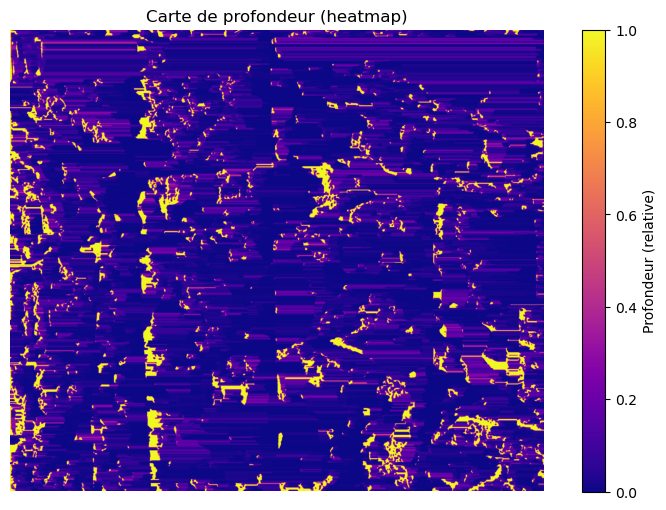

In [153]:
depth = plot_depth_map(
    disp,              # ta carte de disparité
    focal_length=7193.133,  # approx (à adapter)
    baseline=0.380       # 10 cm par ex
)

In [154]:
def plot_depth_final(disparity, f, B):
    disp = disparity.astype(np.float32).copy()
    disp[disp < 1] = 1

    depth = (f * B) / disp

    # inversion pour visualisation intuitive
    depth_vis = 1.0 / depth

    # normalisation robuste
    d_min = np.percentile(depth_vis, 2)
    d_max = np.percentile(depth_vis, 98)

    depth_vis = np.clip(depth_vis, d_min, d_max)
    depth_vis = (depth_vis - d_min) / (d_max - d_min)

    plt.figure(figsize=(10,6))
    plt.imshow(depth_vis, cmap='plasma')
    plt.colorbar(label="Proximité")
    plt.title("Depth map (clean)")
    plt.axis('off')
    plt.show()

    return depth

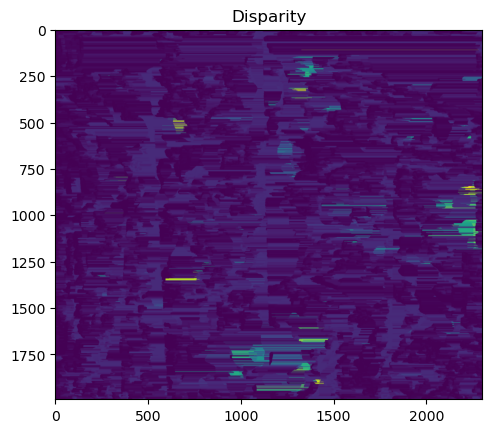

In [157]:
plt.imshow(disp)
plt.title("Disparity")
plt.show()